In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/processed/returns_computed.csv")

print(nav.head())
print(nav.columns)

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692
Index(['amfi_code', 'date', 'nav'], dtype='str')


In [3]:
nav["date"] = pd.to_datetime(nav["date"])

print(nav.dtypes)

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object


In [5]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [6]:
risk_data = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ]

    returns = temp["daily_return"].dropna()

    var95 = np.percentile(
        returns,
        5
    )

    cvar95 = returns[
        returns <= var95
    ].mean()

    risk_data.append(
        [
            code,
            round(var95, 4),
            round(cvar95, 4)
        ]
    )

risk_df = pd.DataFrame(
    risk_data,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

risk_df.head()

KeyError: 'daily_return'

In [7]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [8]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [9]:
print(nav.head())
print(nav.columns.tolist())

   amfi_code       date      nav
0     119551 2022-01-03  54.3856
1     119551 2022-01-04  54.3474
2     119551 2022-01-05  54.6869
3     119551 2022-01-06  55.4550
4     119551 2022-01-07  55.3692
['amfi_code', 'date', 'nav']


In [10]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

print(nav.head())
print(nav.columns.tolist())

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
['amfi_code', 'date', 'nav', 'daily_return']


In [11]:
nav.to_csv(
    "../data/processed/returns_computed.csv",
    index=False
)

print("returns_computed.csv updated")

returns_computed.csv updated


In [12]:
risk_data = []

for code in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == code]

    returns = temp["daily_return"].dropna()

    var95 = np.percentile(
        returns,
        5
    )

    cvar95 = returns[
        returns <= var95
    ].mean()

    risk_data.append(
        [code, round(var95, 4), round(cvar95, 4)]
    )

risk_df = pd.DataFrame(
    risk_data,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

risk_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.0144,-0.0181
1,100025,-0.0038,-0.0050
2,100033,-0.0190,-0.0235
3,101206,-0.0133,-0.0174
4,101207,-0.0260,-0.0325


In [13]:
risk_df.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved")

var_cvar_report.csv saved


In [14]:
fund_code = nav["amfi_code"].unique()[0]

temp = nav[
    nav["amfi_code"] == fund_code
].copy()

rolling_sharpe = (
    temp["daily_return"]
    .rolling(90)
    .mean()
    /
    temp["daily_return"]
    .rolling(90)
    .std()
) * np.sqrt(252)

temp["rolling_sharpe"] = rolling_sharpe

temp[
    ["date", "rolling_sharpe"]
].tail()

,date,rolling_sharpe
6895,2026-05-25,-0.986168
6896,2026-05-26,-0.957388
6897,2026-05-27,-1.244102
6898,2026-05-28,-1.191463
6899,2026-05-29,-1.215738


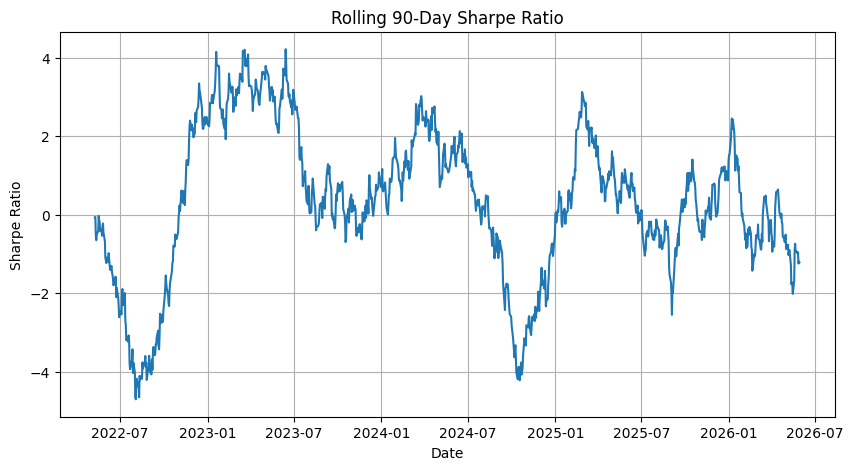

In [15]:
plt.figure(figsize=(10,5))

plt.plot(
    temp["date"],
    temp["rolling_sharpe"]
)

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.grid()

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

In [16]:
transactions = pd.read_csv(
    "../data/processed/08_transactions_clean.csv"
)

print(transactions.head())

  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              Sip        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              Sip         912   
3   INV003436       2024-01-01     118634              Sip        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female                54.4   
4        Delhi      Noida       T30     26-35    Male                14.5   

  payment_mode kyc_status  
0          UPI   Verified  
1       Cheque   Verified  
2      M

In [17]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions["cohort_year"] = (
    transactions["transaction_date"]
    .dt.year
)

print(
    transactions[
        ["transaction_date","cohort_year"]
    ].head()
)

  transaction_date  cohort_year
0       2024-01-01         2024
1       2024-01-01         2024
2       2024-01-01         2024
3       2024-01-01         2024
4       2024-01-01         2024


In [18]:
cohort_df = (
    transactions
    .groupby("cohort_year")
    .agg(
        avg_sip_amount = (
            "amount_inr",
            "mean"
        ),
        total_invested = (
            "amount_inr",
            "sum"
        )
    )
    .reset_index()
)

cohort_df

,cohort_year,avg_sip_amount,total_invested
0,2024,107739.476605,2500633252
1,2025,106704.345527,1020947178


In [19]:
sip_count = (
    transactions
    .groupby("investor_id")
    .size()
    .reset_index(name="txn_count")
)

sip_count.head()

,investor_id,txn_count
0,INV000001,3
1,INV000002,6
2,INV000003,2
3,INV000004,9
4,INV000005,8


In [20]:
active_sip = sip_count[
    sip_count["txn_count"] >= 6
]

print(
    "Active SIP Investors:",
    len(active_sip)
)

Active SIP Investors: 2950


In [21]:
at_risk = sip_count[
    sip_count["txn_count"] < 3
]

print(
    "At Risk Investors:",
    len(at_risk)
)

at_risk.head()

At Risk Investors: 819


,investor_id,txn_count
2,INV000003,2
14,INV000015,2
24,INV000025,1
34,INV000035,2
35,INV000036,2
